# Phase 1 :- Data Understanding

In [2]:
#Step 1
# Importation

import numpy as np
import pandas as pd

In [4]:
# Step 2
# Loading the Dataset

df = pd.read_csv('/Users/soujanyaprokashsingha/Documents/Data Analyst : Science/Professional Projects/Datamites Projects/Insurance-Cost-Prediction/Data/datasets_13720_18513_insurance(1).csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# Step 3
# Dataset Shape

df.shape

(1338, 7)

In [8]:
# Step 4
# Column names

df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [10]:
# Step 5
# Data types and info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
# Step 6 
# Statistical Summary

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [14]:
# Step 7
# Missing values check

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [16]:
# Step 8
# Check duplicate records

df.duplicated().sum()

# Dropping duplicate

df = df.drop_duplicates()

In [18]:
# Step 9 
# Unique Values (Categorical Understanding)

df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [20]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [22]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

# Phase 3 :- EDA

In [ ]:
# Step 1
# Univariate analysis

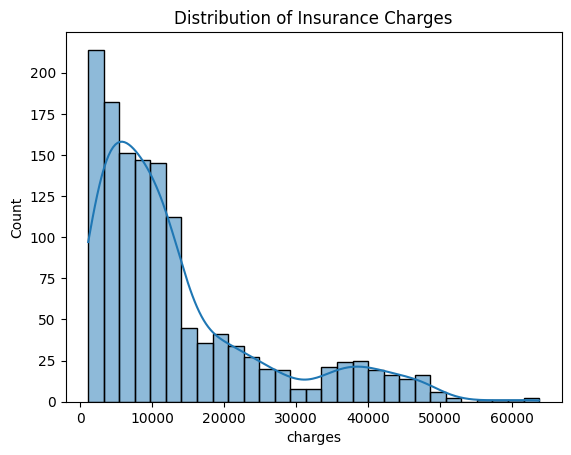

In [24]:
# Distribution of charges

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

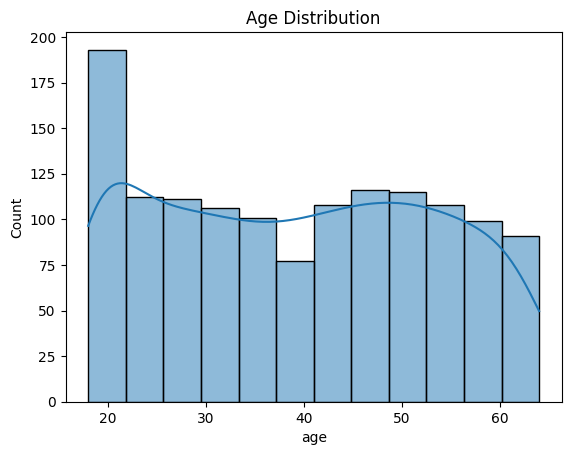

In [26]:
# Distribution of age

sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

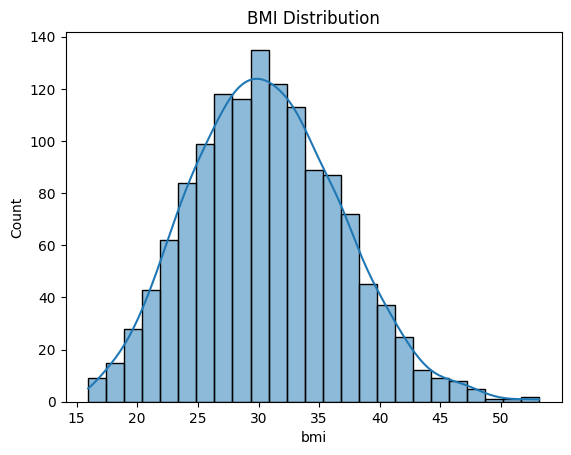

In [28]:
# Distribution of BMI

sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

In [ ]:
# Step 2
# Bivariate analysis

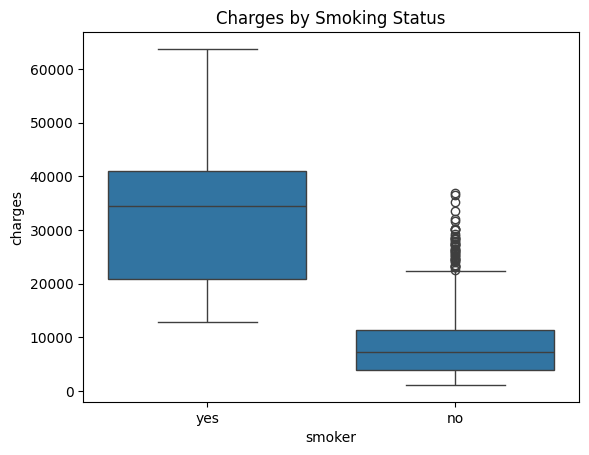

In [32]:
# Smoking vs Charges

sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

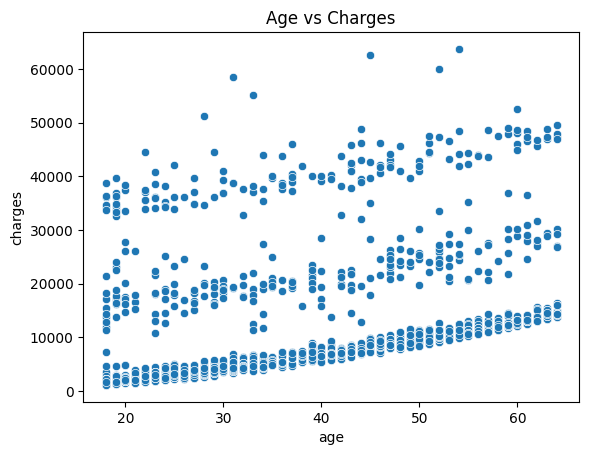

In [34]:
# Age vs Charges

sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

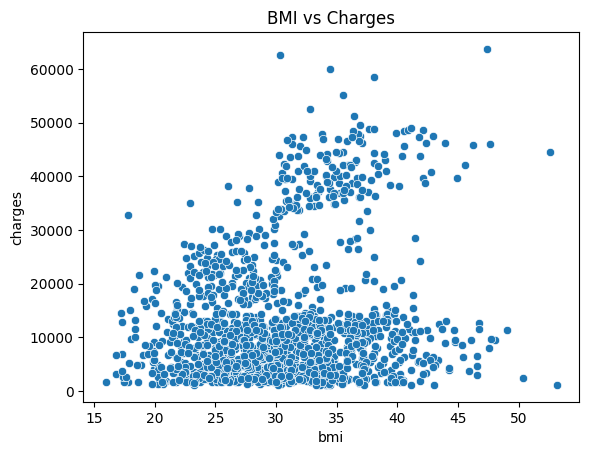

In [36]:
# BMI vs Charges

sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

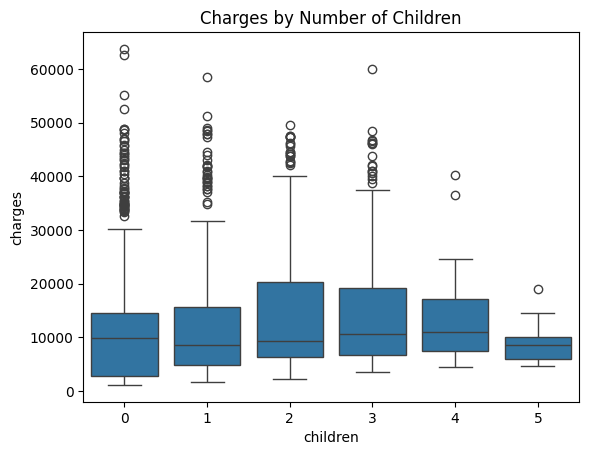

In [38]:
# Children vs Charges

sns.boxplot(x='children', y='charges', data=df)
plt.title("Charges by Number of Children")
plt.show()

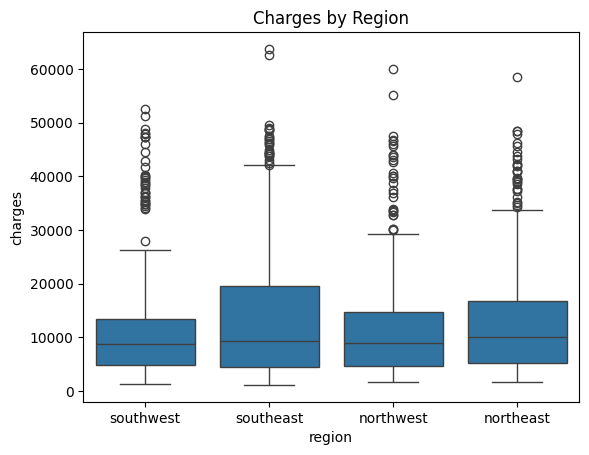

In [40]:
# Region vs Charges

sns.boxplot(x='region', y='charges', data=df)
plt.title("Charges by Region")
plt.show()

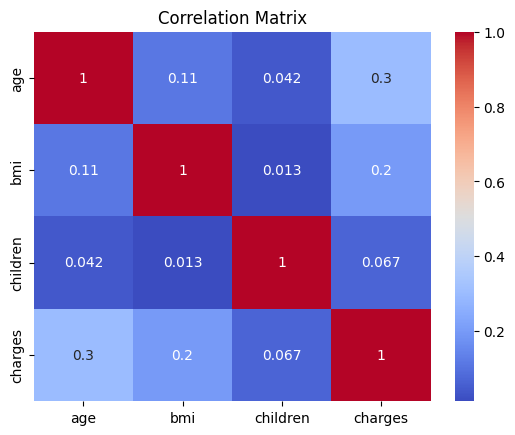

In [42]:
# Step 3
# Multivariation analysis
# Correlation heatmap

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

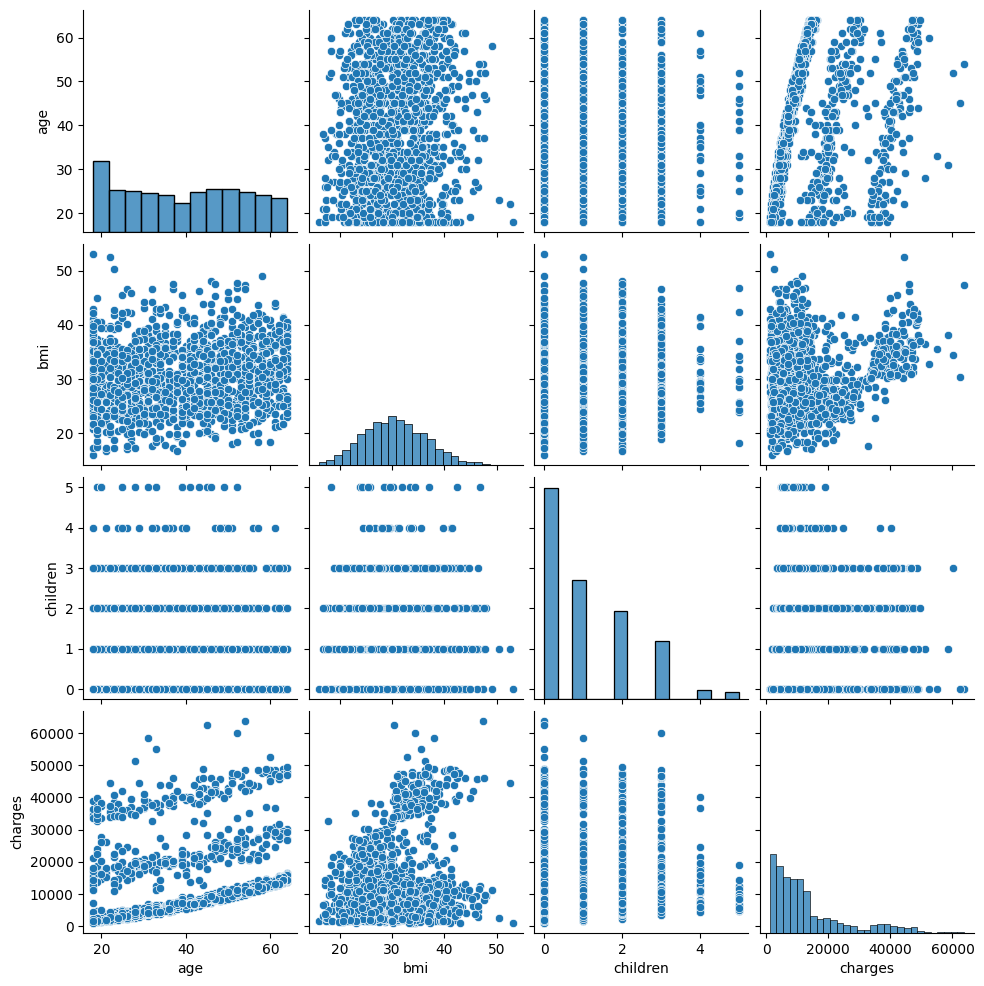

In [48]:
# Relationship with numerical features

sns.pairplot(df)
plt.show()

# Phase 4 :- Data Preprocessing

In [46]:
# Step 1
# Checking missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [50]:
# Step 2
# Handle duplicate records

df.duplicated().sum()
df = df.drop_duplicates()

In [60]:
# Defining features X and Y (target)

X = df.drop('charges', axis=1)
y = df['charges']


In [54]:
# Categorical & numerical columns

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

# Phase 5 :- Feature Engineering

In [56]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

In [58]:
# Splitting Train and Test data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Phase 6 :- Model Building

In [ ]:
# Building a pipeline for model training
# Importing algorithms
# Training the model for each algorithms through the pipeline

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

# Phase 7 :- Model Evaluation

In [64]:
# Step 1
# Import Metrices

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [66]:
results = []

In [68]:
# Calculating the values of the metrices 

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2", "MAE", "RMSE"])
print(results_df)

               Model        R2          MAE         RMSE
0  Linear Regression  0.806929  4177.045561  5956.342894
1      Decision Tree  0.798528  2859.704454  6084.542398
2      Random Forest  0.875529  2715.394247  4782.492117


# Phase 8 :- Model Selection

In [72]:
# Step 1
# Compare Model Performance

results

[['Linear Regression',
  0.8069287081198014,
  4177.045561036321,
  5956.3428943635845],
 ['Decision Tree', 0.7985282478223654, 2859.7044543619404, 6084.542398210889],
 ['Random Forest', 0.8755293820280771, 2715.3942467294773, 4782.492116803109]]

In [74]:
# Select best model based on R2 (or RMSE)

best_model_name = results_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
best_model = pipelines[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


# Phase 9 :- Model saving and finalization

In [90]:
# Checking the path of the file

import os
current_dir = os.getcwd()
current_dir

'/Users/soujanyaprokashsingha/Documents/Data Analyst : Science/Professional Projects/Datamites Projects/Insurance-Cost-Prediction/notebooks'

In [92]:
# Move project to the root folder

project_root = os.path.abspath(os.path.join(current_dir, ".."))

In [94]:
# Creating models folder

models_path = os.path.join(project_root, "models")

os.makedirs(models_path, exist_ok=True)

In [100]:
# Creating and saving the .pkl file

import joblib

model_path = os.path.join(models_path, "insurance_model.pkl")

joblib.dump(best_model, model_path)

['/Users/soujanyaprokashsingha/Documents/Data Analyst : Science/Professional Projects/Datamites Projects/Insurance-Cost-Prediction/models/insurance_model.pkl']

In [102]:
# Creaing and saving the metadata file

import json

metadata = {
    "model_name": best_model_name,
    "features": list(X.columns),
    "target": "charges"
}

metadata_path = os.path.join(models_path, "model_metadata.json")

with open(metadata_path, "w") as f:
    json.dump(metadata, f)

In [104]:
os.listdir(models_path)

['model_metadata.json', 'insurance_model.pkl']

In [ ]:
#
git add .
git commit -m "Added final trained model"
git push origin main